<a href="https://colab.research.google.com/github/mdNotFound/100-days-of-ai-engineering/blob/main/DAY_11_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt

In [21]:
sample_dir="samples"
if not os.path.exists(sample_dir):
  os.makedirs(sample_dir)

In [22]:
latent_size=64
hidden_size=256
image_size=784 ##28 x 28
num_epochs=150
batch_size=100

In [23]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [24]:
def load_mnist_data(batch_size):
  transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])
  mnist=torchvision.datasets.FashionMNIST(
      root="./data",
      train=True,
      transform=transform,
      download=True
  )
  data_loader=torch.utils.data.DataLoader(
      dataset=mnist,
      batch_size=batch_size,
      shuffle=True
  )
  return data_loader

In [25]:
data_loader=load_mnist_data(batch_size)

In [26]:
class Generator(nn.Module):
  def __init__(self,latent_size,hidden_size,image_size):
    super(Generator,self).__init__()
    self.model=nn.Sequential(
        nn.Linear(latent_size,hidden_size),
        nn.LeakyReLU(0.2),
        nn.Linear(hidden_size,hidden_size),
        nn.LeakyReLU(0.2),
        nn.Linear(hidden_size,image_size),
        nn.Tanh()
    )

  def forward(self,z):
    return self.model(z)

generator=Generator(latent_size,hidden_size,image_size).to(device)

In [27]:
print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Tanh()
  )
)


In [28]:
print(f"Total parameters in G: {sum(p.numel() for p in generator.parameters())}")

Total parameters in G: 283920


In [29]:
class Discriminator(nn.Module):
  def __init__(self,image_size,hidden_size):
    super(Discriminator,self).__init__()
    self.model=nn.Sequential(
        nn.Linear(image_size,hidden_size),
        nn.LeakyReLU(0.2),
        nn.Linear(hidden_size,hidden_size),
        nn.LeakyReLU(0.2),
        nn.Linear(hidden_size,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    return self.model(x)
discriminator=Discriminator(image_size,hidden_size).to(device)

In [30]:
print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [31]:
print(f"Total parameters in D: {sum(p.numel() for p in discriminator.parameters())}")

Total parameters in D: 267009


In [32]:
criterion=nn.BCELoss()
d_optimizer_fixed=torch.optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))
g_optimizer_fixed=torch.optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [33]:
def denorm(x):
  out=(x+1)/2
  return out.clamp(0,1)

In [34]:
def reset_grad():
  d_optimizer_fixed.zero_grad()
  g_optimizer_fixed.zero_grad()

In [35]:
total_steps = len(data_loader)
d_losses = []
g_losses = []
num_epochs = 150

for epoch in range(num_epochs):
  epoch_d_loss = 0
  epoch_g_loss = 0
  for i, (images, labels) in enumerate(data_loader):
    # Reshape and move to device
    images = images.reshape(batch_size, -1).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)  # Fixed torch.zeroes typo

    # Train Discriminator
    outputs = discriminator(images)
    real_score = outputs  # Defined real_score for printing
    d_loss_real = criterion(outputs, real_labels)

    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = generator(z)
    outputs = discriminator(fake_images.detach())
    fake_score = outputs
    d_loss_fake = criterion(outputs, fake_labels)

    d_loss = d_loss_real + d_loss_fake
    reset_grad()
    d_loss.backward()
    d_optimizer_fixed.step()

    # Train Generator
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = generator(z)
    outputs = discriminator(fake_images)
    g_loss = criterion(outputs, real_labels)

    reset_grad()
    g_loss.backward()
    g_optimizer_fixed.step()

    epoch_d_loss += d_loss.item()
    epoch_g_loss += g_loss.item()

    if (i+1) % 200 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], "
            f"D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, "
            f"D(x): {real_score.mean().item():.2f}, D(G(z)): {fake_score.mean().item():.2f}")

      d_losses.append(epoch_d_loss / total_steps)
      g_losses.append(epoch_g_loss / total_steps)

      fake_images_grid = fake_images.reshape(fake_images.size(0), 1, 28, 28)
      torchvision.utils.save_image(
          denorm(fake_images_grid),
          os.path.join(sample_dir, f"fake_images-{epoch+1}.png")
      )

Epoch [1/150], Step [200/600], D_loss: 0.3244, G_loss: 1.5784, D(x): 0.99, D(G(z)): 0.27
Epoch [1/150], Step [400/600], D_loss: 0.6514, G_loss: 3.6131, D(x): 0.94, D(G(z)): 0.41
Epoch [1/150], Step [600/600], D_loss: 0.7777, G_loss: 1.6360, D(x): 0.70, D(G(z)): 0.22
Epoch [2/150], Step [200/600], D_loss: 0.4309, G_loss: 2.4751, D(x): 0.87, D(G(z)): 0.22
Epoch [2/150], Step [400/600], D_loss: 0.4301, G_loss: 2.9866, D(x): 0.87, D(G(z)): 0.23
Epoch [2/150], Step [600/600], D_loss: 0.5328, G_loss: 1.9794, D(x): 0.82, D(G(z)): 0.22
Epoch [3/150], Step [200/600], D_loss: 0.6536, G_loss: 2.7110, D(x): 0.84, D(G(z)): 0.33
Epoch [3/150], Step [400/600], D_loss: 0.7806, G_loss: 2.8310, D(x): 0.79, D(G(z)): 0.31
Epoch [3/150], Step [600/600], D_loss: 0.6147, G_loss: 2.2921, D(x): 0.77, D(G(z)): 0.19
Epoch [4/150], Step [200/600], D_loss: 0.6006, G_loss: 2.1173, D(x): 0.75, D(G(z)): 0.14
Epoch [4/150], Step [400/600], D_loss: 0.6767, G_loss: 2.0270, D(x): 0.74, D(G(z)): 0.22
Epoch [4/150], Step [

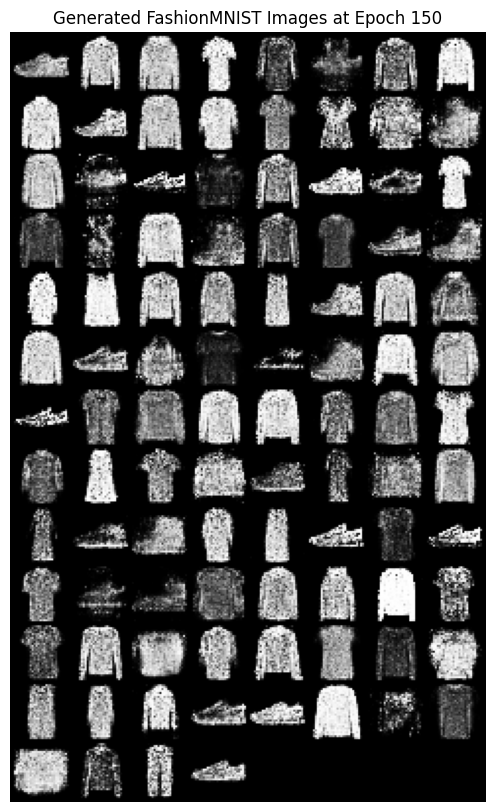

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# We will plot the final generated epoch sample
final_epoch_img_path = os.path.join(sample_dir, 'fake_images-150.png')

if os.path.exists(final_epoch_img_path):
    plt.figure(figsize=(10, 10))
    img = mpimg.imread(final_epoch_img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Generated FashionMNIST Images at Epoch 150')
    plt.show()
else:
    print(f"Could not find the image at {final_epoch_img_path}. Let's list the available files:")
    print(os.listdir(sample_dir)[:10])